In [ ]:
import imageio
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
plt.style.use('ggplot')


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
batch_size=512
epochs=200
sample_size=64
nz=128
k=1

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,)),]) # 이미지 -> 텐서 변환
train_dataset = datasets.MNIST(root="/content/drive/MyDrive/Colab Notebooks/MNIST", train=True, transform=transform, download=True)
train_loader=DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
class Generator(nn.Module):
    def __init__(self,nz):
        super(Generator,self).__init__()
        self.nz=nz
        self.main=nn.Sequential(
            nn.Linear(self.nz, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024,784),
            nn.Tanh()
        )
    def forward(self,x):
        return self.main(x).view(-1,1,28,28)

In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator,self).__init__()
    self.main=nn.Sequential(
        nn.Linear(784,1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(1024,512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(512,256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(256,1),
        nn.Sigmoid()
    )
  def forward(self,x):
    x=x.view(-1,784)
    return self.main(x)

In [ ]:
generator=Generator(nz).to(device)
discriminator=Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [ ]:
optim_g = optim.Adam(generator.parameters(), lr=0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)
criterion=nn.BCELoss()

losses_g=[]
losses_d=[]
images=[]

In [ ]:
def save_generator_image(image,path):
  save_image(image,path)

In [ ]:
def train_discriminator(optimizer,data_real,data_fake):
  b_size=data_real.size(0)
  real_label=torch.ones(b_size,1).to(device)
  fake_label=torch.zeros(b_size,1).to(device)
  optimizer.zero_grad()
  output_real=discriminator(data_real)
  loss_real=criterion(output_real,real_label)
  output_fake=discriminator(data_fake)
  loss_fake=criterion(output_fake,fake_label)
  loss_real.backward()
  loss_fake.backward()
  optimizer.step()
  return loss_real+loss_fake

In [ ]:
def train_generator(optimizer,data_fake):
  b_size=data_fake.size(0)
  real_label=torch.ones(b_size,1).to(device)
  optimizer.zero_grad()
  output=discriminator(data_fake)
  loss=criterion(output,real_label)
  loss.backward()
  optimizer.step()
  return loss

In [26]:
generator.train()
discriminator.train()

for epoch in range(epochs):
  loss_g=0.0
  loss_d=0.0
  for idx,data in tqdm(enumerate(train_loader), total=int(len(train_dataset)/train_loader.batch_size)):

    image,_=data
    image=image.to(device)
    b_size=len(image)
    for step in range(k):
      data_fake = generator(torch.randn(b_size,nz).to(device)).detach()
      data_real=image
      loss_d+=train_discriminator(optim_d,data_real,data_fake)
    data_fake=generator(torch.randn(b_size,nz).to(device))
    loss_g+=train_generator(optim_g,data_fake)
  generated_img = generator(torch.randn(b_size,nz).to(device)).cpu().detach()
  generated_img = make_grid(generated_img)
  save_generator_image(generated_img, f"/content/drive/MyDrive/Colab Notebooks/MNIST/img/gen_img{epoch}.png")
  images.append(generated_img)
  epoch_loss_g=loss_g/idx
  epoch_loss_d=loss_d/idx
  losses_g.append(epoch_loss_g)
  losses_d.append(epoch_loss_d)
  print(f"Epoch {epoch+1} of {epochs}")
  print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

118it [00:12,  9.17it/s]                         

Epoch 1 of 200
Generator loss: 2.69288588, Discriminator loss: 0.62298357



118it [00:12,  9.35it/s]                         

Epoch 2 of 200
Generator loss: 1.97205162, Discriminator loss: 0.78798330



118it [00:11,  9.92it/s]                         

...

Epoch 198 of 200
Generator loss: 1.17688680, Discriminator loss: 1.12615597



118it [00:12,  9.23it/s]                         

Epoch 199 of 200
Generator loss: 1.22056818, Discriminator loss: 1.12073791



118it [00:12,  9.09it/s]                         

Epoch 200 of 200
Generator loss: 1.20466983, Discriminator loss: 1.10332131


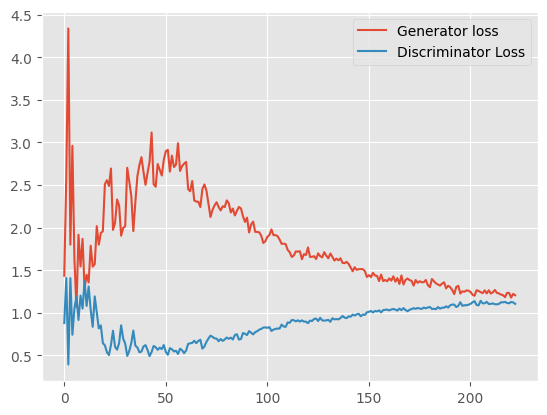

In [27]:
plt.figure()
losses_g = [fl.item() for fl in losses_g]
plt.plot(losses_g, label="Generator loss")
losses_d = [fl.item() for fl in losses_d]
plt.plot(losses_d, label="Discriminator Loss")
plt.legend()

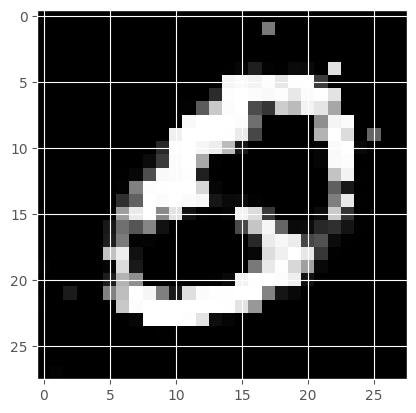

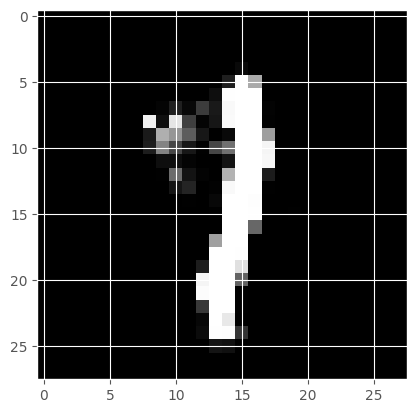

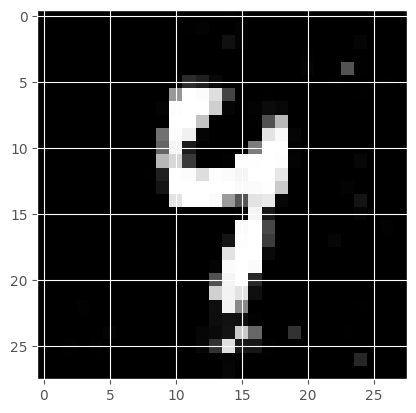

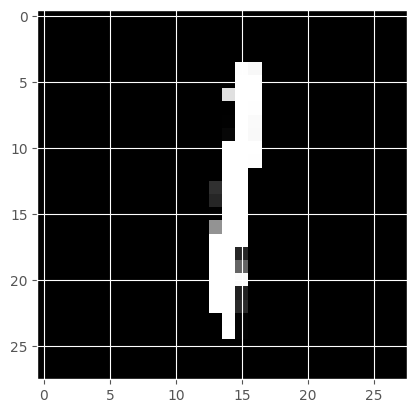

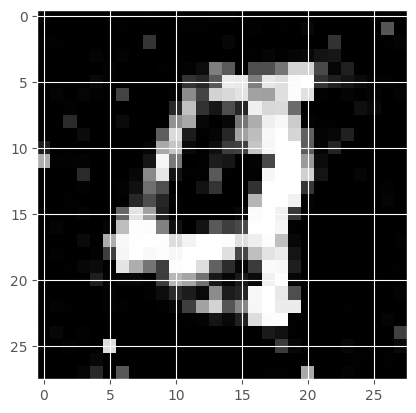

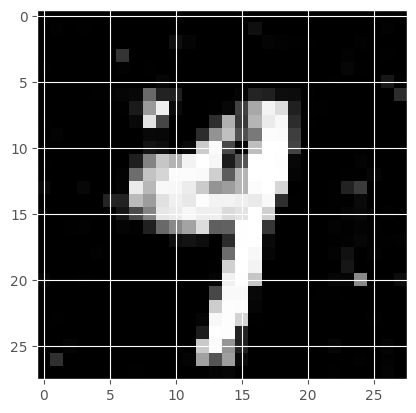

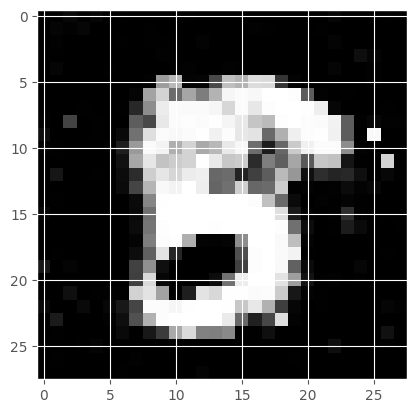

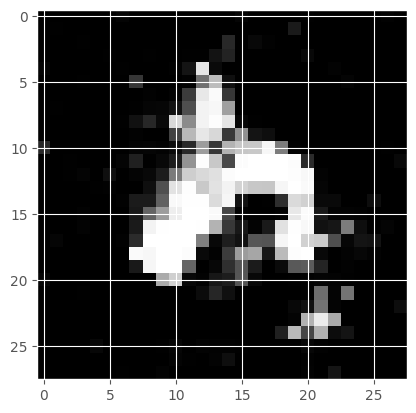

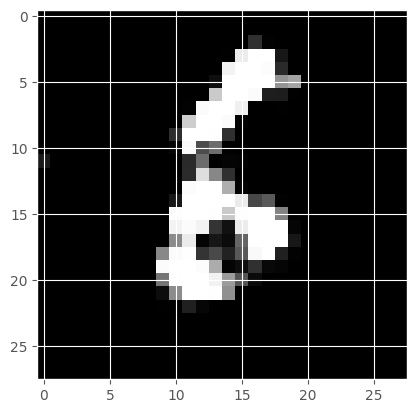

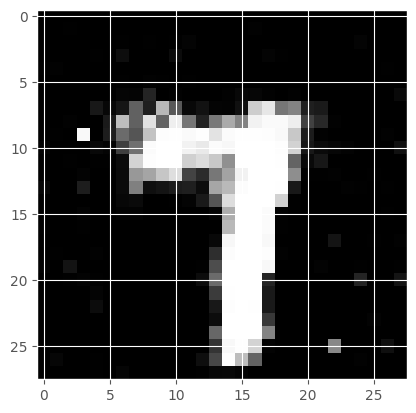

In [29]:
import numpy as np
fake_images = generator(torch.randn(b_size, nz).to(device))
for i in range(10):
  fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i], (28, 28))
  plt.imshow(fake_images_img, cmap='gray')
  plt.savefig("/content/drive/MyDrive/Colab Notebooks/MNIST/fake_images_img"+str(i)+'.png')
  plt.show()